In [ ]:
!pip install -r requirements.txt

# Open Dataset

In [ ]:
import pandas as pd

dataset_path = 'data/sales_data_sample.csv'

df = pd.read_csv(dataset_path, encoding='cp1252')

df.head()

- ORDERNUMBER: unique identifier of each order
- QUANTITYORDERED: number of units ordered
- PRICEEACH: price per unit of the product
- ORDERLINENUMBER: line number within the order (indicates multiple items in the same order)
- SALES: total revenue for the order line (QUANTITYORDERED × PRICEEACH)
- ORDERDATE: date when the order was placed
- STATUS: current status of the order (e.g., Shipped, Cancelled, On Hold)
- QTR_ID: quarter of the year when the order was made
- MONTH_ID: month when the order was made
- YEAR_ID: year when the order was made
- PRODUCTLINE: category or type of product
- MSRP: manufacturer’s suggested retail price
- PRODUCTCODE: unique identifier of the product
- CUSTOMERNAME: name of the customer/company
- PHONE: customer’s contact phone number
- ADDRESSLINE1: primary address of the customer
- ADDRESSLINE2: secondary address (if available)
- CITY: city of the customer
- STATE: state of the customer
- POSTALCODE: postal/ZIP code
- COUNTRY: country of the customer
- TERRITORY: sales region (e.g., NA, EMEA, APAC)
- CONTACTLASTNAME: last name of the contact person
- CONTACTFIRSTNAME: first name of the contact person
- DEALSIZE: size category of the deal (Small, Medium, Large)

In [ ]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

int_cols = [
    'ORDERNUMBER', 'QUANTITYORDERED', 'ORDERLINENUMBER',
    'QTR_ID', 'MONTH_ID', 'YEAR_ID'
]
df[int_cols] = df[int_cols].astype('int64')

float_cols = ['PRICEEACH', 'SALES', 'MSRP']
df[float_cols] = df[float_cols].astype('float64')

cat_cols = [
    'STATUS', 'PRODUCTLINE', 'COUNTRY',
    'TERRITORY', 'DEALSIZE'
]
for col in cat_cols:
    df[col] = df[col].astype('category')

str_cols = [
    'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
    'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE',
    'POSTALCODE', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME'
]
for col in str_cols:
    df[col] = df[col].astype('string')

In [ ]:
df.head()

# Analysis

### Revenue Over Time (Sales Trend Analysis)

In [ ]:
df['year_month'] = df['ORDERDATE'].dt.to_period('M')

monthly_sales = (
    df.groupby('year_month')['SALES']
    .sum()
    .reset_index()
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['year_month'].astype(str), monthly_sales['SALES'])
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

The graph show that the sales is increase over the months. It's important to note that sales exhibit strong seasonal patterns, with pronounced peaks in Q4, especially in October, indicating that the business experiences significantly higher demand during the end-of-year period.

### Perfomance by product line 

In [ ]:
product_sales = (
    df.groupby('PRODUCTLINE')['SALES']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=product_sales, x='SALES', y='PRODUCTLINE')
plt.title('Revenue by Product Line')
plt.xlabel('Total Revenue')
plt.ylabel('Product Line')
plt.show()

In [ ]:
df.groupby('PRODUCTLINE')['SALES'].mean()

The analysis reveals that revenue is highly concentrated in a few product lines, particularly Classic Cars, suggesting that business performance heavily depends on these categories.

### Country Analysis

In [ ]:
country_sales = (
    df.groupby('COUNTRY')['SALES']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=country_sales, x='SALES', y='COUNTRY')
plt.title('Revenue by Country')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.show()

In [ ]:
df.groupby('COUNTRY')['SALES'].sum()

In [ ]:
df.groupby('COUNTRY')['ORDERNUMBER'].nunique()

In [ ]:
df.groupby(['COUNTRY', 'PRODUCTLINE'])['SALES'].sum()

The geographic analysis reveals a strong concentration of revenue in the United States, which significantly outperforms all other countries. Spain and France stand out as important secondary markets, while many other countries contribute only marginally, suggesting opportunities for expansion or optimization

### Customer Revenue

In [ ]:
top_customers = (
    df.groupby('CUSTOMERNAME')['SALES']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

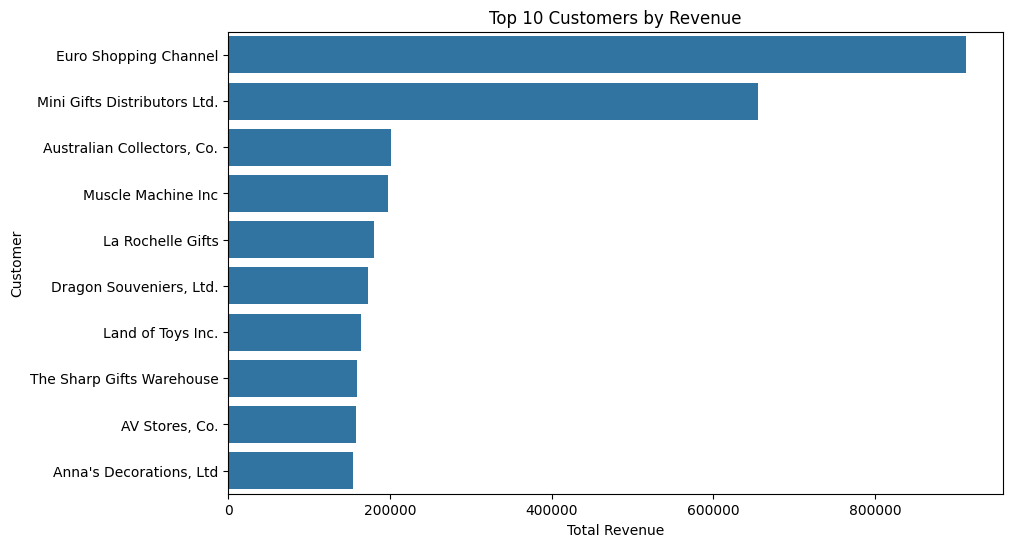

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=top_customers, x='SALES', y='CUSTOMERNAME')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Customer')
plt.show()

In [21]:
df.groupby('CUSTOMERNAME')['ORDERNUMBER'].nunique()

CUSTOMERNAME
AV Stores, Co.                 3
Alpha Cognac                   3
Amica Models & Co.             2
Anna's Decorations, Ltd        4
Atelier graphique              3
                              ..
Vida Sport, Ltd                2
Vitachrome Inc.                3
Volvo Model Replicas, Co       4
West Coast Collectables Co.    2
giftsbymail.co.uk              2
Name: ORDERNUMBER, Length: 92, dtype: int64

In [22]:
df.groupby(['CUSTOMERNAME','PRODUCTLINE'])['SALES'].sum()

CUSTOMERNAME       PRODUCTLINE 
AV Stores, Co.     Classic Cars    61072.54
                   Ships           21111.84
                   Trains           8037.14
                   Vintage Cars    67586.29
Alpha Cognac       Classic Cars    20743.56
                                     ...   
giftsbymail.co.uk  Classic Cars     4128.96
                   Planes          24409.53
                   Ships           26399.49
                   Trains           4598.40
                   Vintage Cars    18704.46
Name: SALES, Length: 399, dtype: float64

The analysis reveals a strong concentration of revenue among a few key customers, with Euro Shopping Channel and Mini Gifts Distributors leading significantly. This indicates a dependency on high-value clients, while the remaining customers contribute more evenly across a lower revenue range